## Sentiment Analysis Project

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer , CountVectorizer
from sklearn.model_selection import train_test_split , StratifiedKFold , GridSearchCV,cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression , SGDClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from sklearn.ensemble import StackingClassifier
from sklearn.calibration import CalibratedClassifierCV

### Load Datasets

In [3]:
sentiment = pd.read_csv('D://jupiter NOTE//scikit-learn//project//sentiment dataset.csv')

### Data Clean and PreProcessing 

In [682]:
sentiment.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,Sentiment_simplify
0,enjoy a beauti day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,Possitive
1,traffic wa terribl thi morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,Negative
2,just finish an amaz workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,Possitive
3,excit about the upcom weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,Possitive
4,tri out a new recip for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,Neutral


### EDA

In [4]:
sentiment = sentiment.drop(['Unnamed: 0.1' , 'Unnamed: 0'] , axis = 1)

In [5]:
sentiment.shape

(732, 13)

In [6]:
sentiment.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Text       732 non-null    str    
 1   Sentiment  732 non-null    str    
 2   Timestamp  732 non-null    str    
 3   User       732 non-null    str    
 4   Platform   732 non-null    str    
 5   Hashtags   732 non-null    str    
 6   Retweets   732 non-null    float64
 7   Likes      732 non-null    float64
 8   Country    732 non-null    str    
 9   Year       732 non-null    int64  
 10  Month      732 non-null    int64  
 11  Day        732 non-null    int64  
 12  Hour       732 non-null    int64  
dtypes: float64(2), int64(4), str(7)
memory usage: 74.5 KB


In [7]:
sentiment.describe()

,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
std,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414
min,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


### Missing Data Handle

In [6]:
sentiment.isna().sum()

Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64

### Handling Date column

In [7]:
sentiment['Timestamp'] = pd.to_datetime(sentiment['Timestamp'])
sentiment['Timestamp'].dtype

dtype('<M8[us]')

In [14]:
sentiment['User'].unique()[1]

'CommuterX'

### Removing Extra Spaces

In [8]:
sentiment['User'] = sentiment['User'].apply(lambda x : x.replace(' ',''))
sentiment['User'][1]

'CommuterX'

In [9]:
sentiment['Platform'].unique()

<StringArray>
[' Twitter  ', ' Instagram ', ' Facebook ', ' Twitter ']
Length: 4, dtype: str

In [10]:
sentiment['Platform'] = sentiment['Platform'].apply(lambda x : x.replace(' ',''))
sentiment['Platform'][0]

'Twitter'

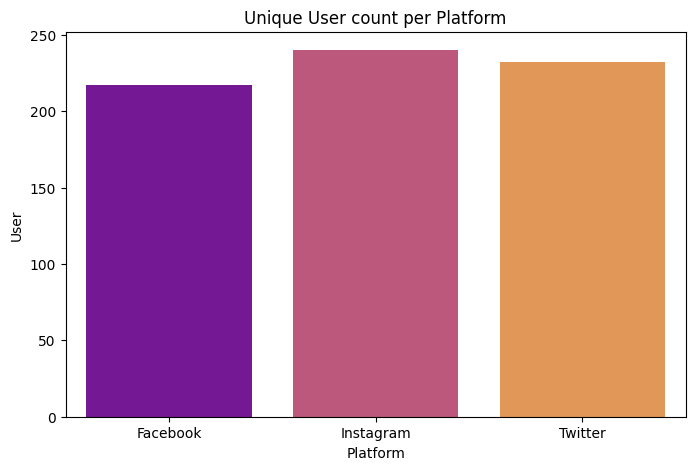

In [11]:
plt.figure(figsize = (8,5))
platform_user = sentiment.groupby('Platform')['User'].nunique().reset_index()
sns.barplot(data = platform_user , x = 'Platform' , y ='User' , hue = 'Platform',
            palette = 'plasma')
plt.title('Unique User count per Platform')
plt.show()

In [220]:
sentiment['Country'].unique()

<StringArray>
[  ' USA      ',   ' Canada   ', ' USA        ',   ' UK       ',
  ' Australia ',   ' India    ',     ' USA    ',          'USA',
  ' Canada    ',  ' USA       ',
 ...
     ' Norway ',   ' Colombia ',    ' Ireland ',    ' Jamaica ',
      ' Kenya ',   ' Scotland ',   ' Thailand ',         ' USA',
      ' Canada',          ' UK']
Length: 115, dtype: str

In [12]:
sentiment['Country'] = sentiment['Country'].apply(lambda x: x.replace(' ', ''))
sentiment['Country'][1]

'Canada'

In [222]:
sentiment['Sentiment'].unique()

<StringArray>
[   ' Positive  ',    ' Negative  ',    ' Neutral   ', ' Anger        ',
 ' Fear         ', ' Sadness      ', ' Disgust      ', ' Happiness    ',
 ' Joy          ', ' Love         ',
 ...
      ' Disgust ',       ' Relief ',     ' Positive ',  ' Embarrassed ',
  ' Mischievous ',          ' Sad ',         ' Hate ',          ' Bad ',
      ' Neutral ',        ' Happy ']
Length: 279, dtype: str

In [13]:
sentiment['Sentiment'] = sentiment['Sentiment'].apply(lambda x: x.replace(' ',''))
sentiment['Sentiment'].unique()

<StringArray>
[         'Positive',          'Negative',           'Neutral',
             'Anger',              'Fear',           'Sadness',
           'Disgust',         'Happiness',               'Joy',
              'Love',
 ...
  'RunwayCreativity',    'Ocean'sFreedom', 'WhispersofthePast',
            'Relief',       'Embarrassed',       'Mischievous',
               'Sad',              'Hate',               'Bad',
             'Happy']
Length: 191, dtype: str

### sentiment Simplify

In [14]:
#To make the model more stable and pratical we simplify all sentiment label -
# into 3 main categories (possitive , negetive , neutral) to reduce complexity.
#handel class imbalance , and improve model performace.

#1. Possitive - all happy , joyful , loving ....
#2.negetive - all sad negetive meaning
#3.neutral - all emotion balanced..

#Easier to train
#More stable 
# Common in sentiment analysis

def simplify_sentiment(label):

    label = str(label).lower().strip()
    #possitive category 
    possitive_key = [
        'positive', 'happy', 'joy', 'love', 'gratitude', 'excitement', 
        'amusement', 'admiration', 'affection', 'awe', 'calmness', 
        'contentment', 'elation', 'enthusiasm', 'hope', 'optimism',
        'pride', 'relief', 'satisfaction', 'serenity', 'thrill',
        'wonder', 'inspiration', 'empowerment', 'bliss', 'cheer',
        'playful', 'curiosity', 'enjoyment', 'happiness', 'delight',
        'euphoria', 'appreciation', 'amazement', 'adoration',
        'anticipation', 'kind', 'compassion', 'proud', 'grateful',
        'elegance', 'radiance', 'rejuvenation', 'coziness', 'blissful',
        'tenderness', 'arousal', 'fulfillment', 'reverence'
    ]

    negative_key = [
       'negative', 'sad', 'anger', 'fear', 'disgust', 'sadness', 
        'bitter', 'confusion', 'disappointed', 'frustration', 
        'grief', 'jealousy', 'loneliness', 'regret', 'shame',
        'anxiety', 'despair', 'hate', 'heartbreak', 'pain',
        'sorrow', 'gloom', 'misery', 'distress', 'agony',
        'anguish', 'depression', 'hopeless', 'mourning', 'grief',
        'resentment', 'envy', 'boredom', 'intimidation', 'helplessness',
        'numbness', 'melancholy', 'ambivalence', 'desperation',
        'suffering', 'betrayal', 'isolation', 'darkness', 'devastated'
    ]

    if 'neutral' in label:
        return 'Neutral'
    if any(word in label for word in possitive_key):
        return 'Possitive'
    if any(word in label for word in negative_key):
        return 'Negative'
    return 'Neutral'

In [15]:
sentiment['Sentiment_simplify'] = sentiment['Sentiment'].apply(simplify_sentiment)

In [22]:
sentiment['Sentiment_simplify'].nunique()

3

In [16]:
sentiment['Sentiment_simplify'].value_counts()

Sentiment_simplify
Possitive    371
Neutral      211
Negative     150
Name: count, dtype: int64

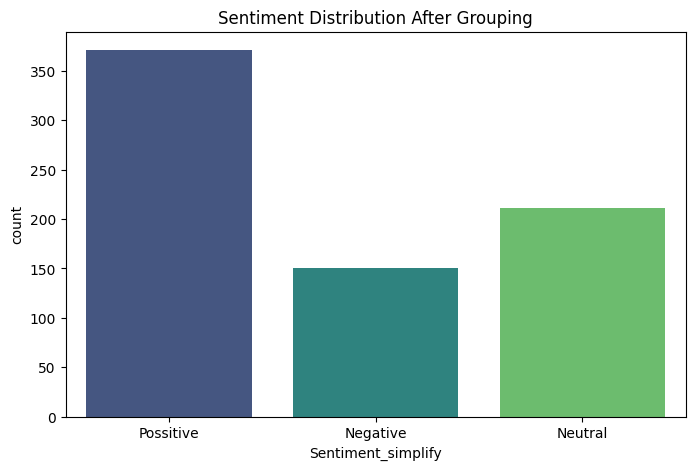

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=sentiment, x='Sentiment_simplify',hue='Sentiment_simplify',
              palette='viridis')
plt.title('Sentiment Distribution After Grouping')
plt.show()

In [25]:
sentiment['Text'] = sentiment['Text'].str.strip().str.lower()

### Stemming

In [18]:
# Stemming reduces word to their root (base) form
# Ex : [love , loveing  , loved , loves] --> [love , love , love , love]
#reduces vocabulary size
#improvs model efficiency
#Help machine learning focus on meaning ,instead of word variations.

from nltk import PorterStemmer

ps = PorterStemmer()
def stem_fun(text):
    y =[]
    for i in text.split():
         y.append(ps.stem(i))
    return ' '.join(y)

In [19]:
sentiment['Text'] = sentiment['Text'].apply(stem_fun)

In [20]:
sentiment['Text'][1]

'traffic wa terribl thi morning.'

In [21]:
#encodeing convert categorical label into numerical value.

X = sentiment['Text']
encode = LabelEncoder()
y = encode.fit_transform(sentiment['Sentiment_simplify'])

### Train test Split

In [22]:
X_train , X_test , y_train , y_test  = train_test_split(X , y , test_size = 0.2 , 
                                            stratify=y,random_state = 42)

In [23]:
print('X_train shape :',X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape :,',y_train.shape)
print('y_test shape :', y_test.shape)

X_train shape : (585,)
X_test shape : (147,)
y_train shape :, (585,)
y_test shape : (147,)


### TF - IDF Vectorization

In [139]:
#  TF - IDF ( Term Frequency - Inverse Document
# convert Text  into numerical features so that machine models can understand 
#it.
# Reduces the importance of very common words that appear in many documents.
# imporoves classification performance.

#Max _ feature  : limits vocabulary size
# stop_words :  removes common English words
# ngram_range  : captures word combinations

#  LogisticRegression

# max_iter = 2000 (increase the maximum number of iterations for the solver to converge.)
# class_weight = 'balanced'  (automatic adjusts weights inversly proportional to the frequencies.)
# This helps if classes (possitve , negative , neutral ) are imbalanced.


pipeline = Pipeline([
      ('vectorizer', TfidfVectorizer(max_features=3000, stop_words='english',
                                         ngram_range=(1,3))),
      ('model', LogisticRegression(max_iter=2000 , class_weight = 'balanced',
                            random_state = 42))
])

### Train Model

In [140]:
pipeline.fit(X_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [141]:
y_pred = pipeline.predict(X_test)

In [142]:
#accuracy_score is the ratic of correct predictions to the toatl number of preditions.
# y_test - actual label form the test data
# y_pred  -  labels predicted by the model

# accuracy : 81.63 %  ( here correctly classified by your model into the categories : Possitive , Negetive , neutral
# correct prediction : 0.8163 * 147 = 120 (Approximately)(posts/text).
# remainining 27 posts were misclassified.


#classification_report 
#(TP = True Posstive ) , (FN = False Negative)
# Precision :-  how many were correct (F : TP /(TP + FP))
# recall :- how many did the model correct :- (F : TP ( TP + FN))
# f1- score :- balance both matrics :- (F : 2 *(precision * recall) / (precision + recall)

accuracy = accuracy_score(y_test , y_pred)
print(accuracy)
print(f'accurancy :{accuracy * 100 :.2f} %')
classific = classification_report(y_test , y_pred)
print(classific)

0.8163265306122449
accurancy :81.63 %
              precision    recall  f1-score   support

           0       0.89      0.83      0.86        30
           1       0.69      0.69      0.69        42
           2       0.86      0.88      0.87        75

    accuracy                           0.82       147
   macro avg       0.81      0.80      0.81       147
weighted avg       0.82      0.82      0.82       147



In [143]:
new_text = [
    "I love this sunny weather!",
    "Traffic was terrible today...",
    "Just finished my work, nothing special."
]

y_pred = pipeline.predict(new_text)

pred_labels = encode.inverse_transform(y_pred)

for text , label in zip(new_text , pred_labels):
    print(f"Text: {text}\nPredicted Sentiment: {label}\n")

Text: I love this sunny weather!
Predicted Sentiment: Negative

Text: Traffic was terrible today...
Predicted Sentiment: Possitive

Text: Just finished my work, nothing special.
Predicted Sentiment: Possitive



In [60]:
#LinearSVC 
#(Linear support vector classifier) used for text classification tasks like sentiment analysis.


#SGDClassifier (Stochastic Gradient Descent Classifer)
#This is Fast and scalable for large datasets.
# loss='log_loss : uses logistic reg loss.so it behaves like a logistic Regression classifier.
# max_iter=2000: Maximum iterations to converge.
#class_weight='balanced' : handel class imbalance automatically.
models ={
       'Linear':LinearSVC(C=2 , class_weight='balanced' , max_iter=3000) , 
        'sgd': SGDClassifier( loss='log_loss',  
                        max_iter=2000,
                       class_weight='balanced')
}
for name , model in models.items():

        pipe = Pipeline([
             ('vectorizer', TfidfVectorizer(max_features=5000, stop_words='english')),
              ('model', model)
])

pipe.fit(X_train , y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [61]:
y_pred1 = pipe.predict(X_test)

In [63]:
# accuracy : 80.27 % ( here correctly classified by your model into the categories : Possitive , Negetive , neutral
# correct prediction : 0.8027 * 147 = 118 (Approximately) (posts/text).
# remainining 27 posts were misclassified.


accuracy = accuracy_score(y_test , y_pred1)
print(accuracy)
print(f'accurancy :{accuracy * 100 :.2f} %')
classific = classification_report(y_test , y_pred1)
print(classific)

0.8027210884353742
accurancy :80.27 %
              precision    recall  f1-score   support

           0       0.88      0.77      0.82        30
           1       0.71      0.64      0.68        42
           2       0.82      0.91      0.86        75

    accuracy                           0.80       147
   macro avg       0.80      0.77      0.79       147
weighted avg       0.80      0.80      0.80       147



In [137]:
new_text = [
    "I love this sunny weather!",
    "Traffic was terrible today...",
    "Just finished my work, nothing special."
]

y_pred = pipe.predict(new_text)

pred_labels = encode.inverse_transform(y_pred)

for text , label in zip(new_text , pred_labels):
    print(f"Text: {text}\nPredicted Sentiment: {label}\n")

Text: I love this sunny weather!
Predicted Sentiment: Negative

Text: Traffic was terrible today...
Predicted Sentiment: Negative

Text: Just finished my work, nothing special.
Predicted Sentiment: Possitive



In [125]:
# lr : strong baseline linear model , sgd : fast linear model for large datasets

#stacking
#It is ensemble learning method that combines multiple model(called base_estimators) to make a final prediction.
#estimators = base_estimator :(the base models to combine)
#cv = 5 : users 5 fold cross-validation to generate out of fold predictions.
#stack_method='predict_proba':(use predicted probabilities from base models instead of class lables.

#work
#Text Data --> TF-IDF --> Base Models (LR, SGD) --> Base Predictions --> Final Prediction

base_estimator = [
    ('lr', LogisticRegression(C=1.5, class_weight='balanced', max_iter=2000)),
    ('sgd', SGDClassifier(loss='log_loss', class_weight='balanced', max_iter=3000))
]


stacking_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=3000,
        ngram_range=(1, 3),
        stop_words='english',
        min_df=1,
        max_df=0.8
    )),
    ('stacking', StackingClassifier(
        estimators=base_estimator,
        cv=5,
        stack_method='predict_proba'
    ))
])
stacking_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vectorizer', ...), ('stacking', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [133]:
y_pred_stack = stacking_pipeline.predict(X_test)
stack_acc = accuracy_score(y_test, y_pred_stack)
print(f"Stacking Classifier: {stack_acc*100:.2f}%")
classific = classification_report(y_test , y_pred_stack)
print(classific)

Stacking Classifier: 84.35%
              precision    recall  f1-score   support

           0       0.90      0.87      0.88        30
           1       0.77      0.71      0.74        42
           2       0.86      0.91      0.88        75

    accuracy                           0.84       147
   macro avg       0.84      0.83      0.84       147
weighted avg       0.84      0.84      0.84       147



In [136]:
new_text = [
    "I love this sunny weather!",
    "Traffic was terrible today...",
    "Just finished my work, nothing special."
]

y_pred = stacking_pipeline.predict(new_text)

pred_labels = encode.inverse_transform(y_pred)

for text , label in zip(new_text , pred_labels):
    print(f"Text: {text}\nPredicted Sentiment: {label}\n")

Text: I love this sunny weather!
Predicted Sentiment: Negative

Text: Traffic was terrible today...
Predicted Sentiment: Possitive

Text: Just finished my work, nothing special.
Predicted Sentiment: Possitive

